# Section 3 - Model Creation, Hyperparameter Search, and Model Evaluation 

**Using Random Forest**

1. Train/test split
2. Implement RandomForestClassifier 
3. Hyperparameter Tuning using RandomizedSearchCV
4. Retrain model using final hyperparameters
5. Generate new predictions for this new model
4. F1 score evaluation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# accuracy metrics
from sklearn.metrics import (f1_score, classification_report, confusion_matrix, 
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)

# train/test/CV split and tuning tools
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# used to measure how long each search takes
import time

In [2]:
df = pd.read_csv('../data/clean_bank_transactions.csv')
df.head()

,step,amount,isFraud,balance_change_orig,balance_change_dest,balance_mismatch,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,0,-9839.64,0.0,1.455192e-11,0,0,1,0
1,1,1864.28,0,-1864.28,0.0,1.136868e-12,0,0,1,0
2,1,181.00,1,-181.00,0.0,0.000000e+00,0,0,0,1
3,1,181.00,1,-181.00,-21182.0,0.000000e+00,1,0,0,0
4,1,11668.14,0,-11668.14,0.0,0.000000e+00,0,0,1,0


In [3]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

### Split Train and Test Sets

Using stratify parameter helped guarantees that fraud ratio in both test and train sets are roughly at 0.13%.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train: ", X_train.shape)
print("Test: ", X_test.shape)
print("Fraud cases in training set: ", y_train.sum())
print("Fraud cases in test set: ", y_test.sum())

Train:  (5090096, 9)
Test:  (1272524, 9)
Fraud cases in training set:  6570
Fraud cases in test set:  1643


### Baseline - Random Forest Model

In [5]:
start = time.time()
rf_baseline = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)
elapsed_grid = time.time() - start

yhat_baseline = rf_baseline.predict(X_test)

f1_score_baseline = f1_score(y_test, yhat_baseline)

print(f"Time:     {elapsed_grid:.2f}s")
print(f"F1 Score: {f1_score_baseline:.4f}")
print()

print("Confusion Matrix \n", confusion_matrix(y_test, yhat_baseline))
print()

print(f"\nClassification Report:\n{classification_report(y_test, yhat_baseline)}")

Time:     252.90s
F1 Score: 0.8488

Confusion Matrix 
 [[1270834      47]
 [    397    1246]]


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.96      0.76      0.85      1643

    accuracy                           1.00   1272524
   macro avg       0.98      0.88      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



##### Baseline Results Interpretation 
F1 score of 0.84 without tuning is good, but we'll try to make it better.

RECALL vs PRECISION
- Precision for fraud = 0.96 meaning when model says something fraud, it's right 96% of the time. (few false alarms)
- Recall for fraud = 0.76 - model catching 76% of actual fraud cases. - missed a fraud case (told someone they dont have cancer, even if they do)

### Hyperparameter Tuning

In [6]:
# training search on 500k rows, will retrain once best hyperparameters are found on full dataset later.
X_train_sample = X_train.sample(500000, random_state=42)
y_train_sample = y_train[X_train_sample.index]

param_dist = {
    "n_estimators":[100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "class_weight": ['balanced', None],  #Handle class imbalance using class weight
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


start = time.time()

# Set up RandomizedSearchCV with 5-fold cross-validation
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_sample, y_train_sample)
elapsed_grid = time.time() - start

yhat_random = rf_random.predict(X_test)

print(f"Time:               {elapsed_grid:.2f}s")
print(f"Best F1 Score (CV): {rf_random.best_score_:.4f}")
print(f"Best Parameters:    {rf_random.best_params_}")


Time:               636.92s
Best F1 Score (CV): 0.8389
Best Parameters:  {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': None}


### Extra Hyperparameter Testing

The following is an attempt to manually find the best hyperparametes combined with cv folds and n_iter.


---
**With CV folds = 5 and hyperparameters:**\
param_dist = {\
    "n_estimators":[100, 200, 300],\
    "max_depth": [10, 20, 30, None],\
    "class_weight": ['balanced', None]\
}



|   | n_estimators | max_depth | class_weight | F1-Score
| -------- | -------- | -------- | -------- | -------- 
| n_iter=5, cv=5 | 200 | 20 | None | 0.8341
| n_iter=10, cv=5 | 200 | 10 | None | 0.8372


**With CV folds = 5 and hyperparameters:**\
param_dist = {\
    "n_estimators":[100, 200, 300],\
    "max_depth": [10, 20, 30, None],\
    "class_weight": ['balanced', None],\
    'min_samples_split': [2, 5, 10],\
    'min_samples_leaf': [1, 2, 4]\
}



|   | n_estimators | max_depth | class_weight | min_samples_split | min_samples_leaf | F1-Score
| -------- | -------- | -------- | -------- | -------- | -------- | --------
| n_iter=5, cv=5 | 100 | 20 | None | 5 | 1 | 0.8376
| n_iter=10, cv=5 | 200 | 10 | None | 5 | 1 | 0.8389

---

### Retraining Model Using Best Hyperparameter

In [11]:
# Retrain final model with best hyperparameters on full training set
start = time.time()

rf_best = RandomForestClassifier(
    n_estimators=100,     
    min_samples_split=5,  
    min_samples_leaf=1,    
    max_depth=20,         
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train, y_train)
elapsed_grid = time.time() - start

yhat_best = rf_best.predict(X_test)

f1_score_best = f1_score(y_test, yhat_best)

confusion = confusion_matrix(y_test, yhat_best)


print(f"Time:     {elapsed_grid:.2f}s")
print(f"F1 Score: {f1_score_best:.4f}")

print("\nConfusion Matrix \n", confusion_matrix(y_test, yhat_best))
print()


print(f"\nClassification Report:\n{classification_report(y_test, yhat_baseline)}")

Time:     372.82s
F1 Score: 0.8437

Confusion Matrix 
 [[1270852      29]
 [    423    1220]]


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.96      0.76      0.85      1643

    accuracy                           1.00   1272524
   macro avg       0.98      0.88      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



Our confusion matrix reveals that the tuned model had:
- 1,220 fraud transactions correctly caught
- 423 fraud transactions missed (these are the most imporantant and could have serious implications)
- 29 legitimate transactions falsely flagged 


### Comparing Baseline vs. Tuned Model

In [16]:
print("=" * 42)
print(f"{'':<25} {'F1-Score':>8}")
print("-" * 42)
print(f"{'Baseline Model':<25} {f1_score_baseline:.4f}")
print(f"{'Tuned Model':<25} {f1_score_best:.4f}")
print("=" * 42)

                          F1-Score
------------------------------------------
Baseline Model            0.8488
Tuned Model               0.8437


As we can see, the hyperparameter tuning did not have a huge impact on the model's performance. The baseline model did slightly better than the tuned model by 0.005. This seems backwards but this is explained by the fact that the tuned model is more honest than a single train/test split. Cross Validation split the data into 5 different ways and averages the score, which makes the tuned model's F1 Score more reliable.

The model's precision is really good, 96% correct when the model says something fraud, but recalls is when it struggles specifically missing 423 or 24% of fraudulent transactions. But some improvements could be done in handling the class imbalance using SMOTE or higher class weights.

### Feature Importance

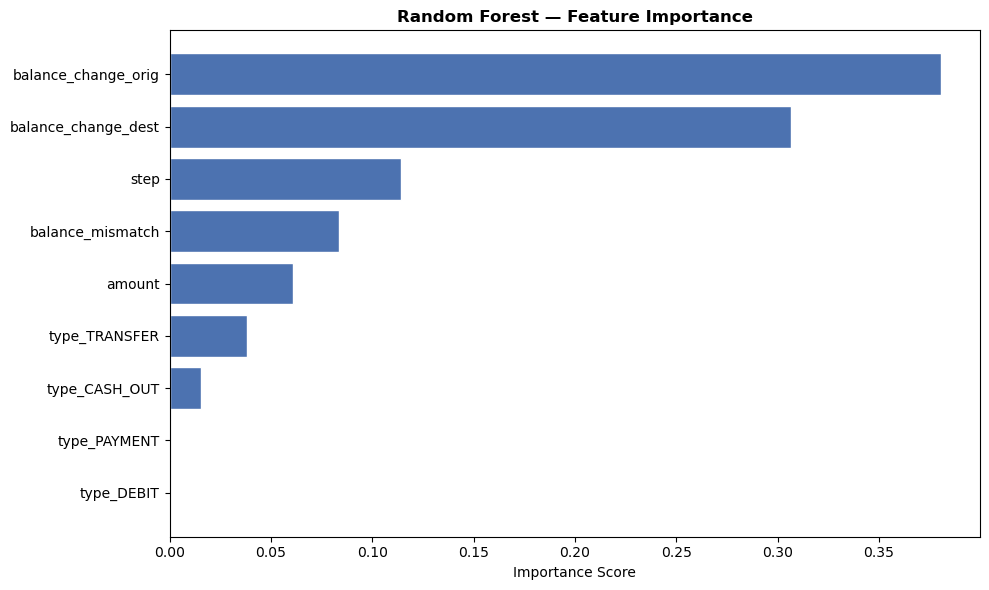

In [20]:
# Get feature importances from trained model
feature_importance = pd.Series(
    rf_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)


plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance.index, feature_importance.values, 
                color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

The above chart confirms what we found in EDA. The two features we engineered (balance_change_orig and balance_change_dest) turned out to be the most useful for the model, which makes sense since fraudsters consistently drain accounts completely. step, balance_mismatch, and amount contributed moderately, while type_PAYMENT and type_DEBIT scored near zero were expected since those transaction types had no fraud cases at all.

### Confusion Matrix Heatmap and ROC-AUC Curve

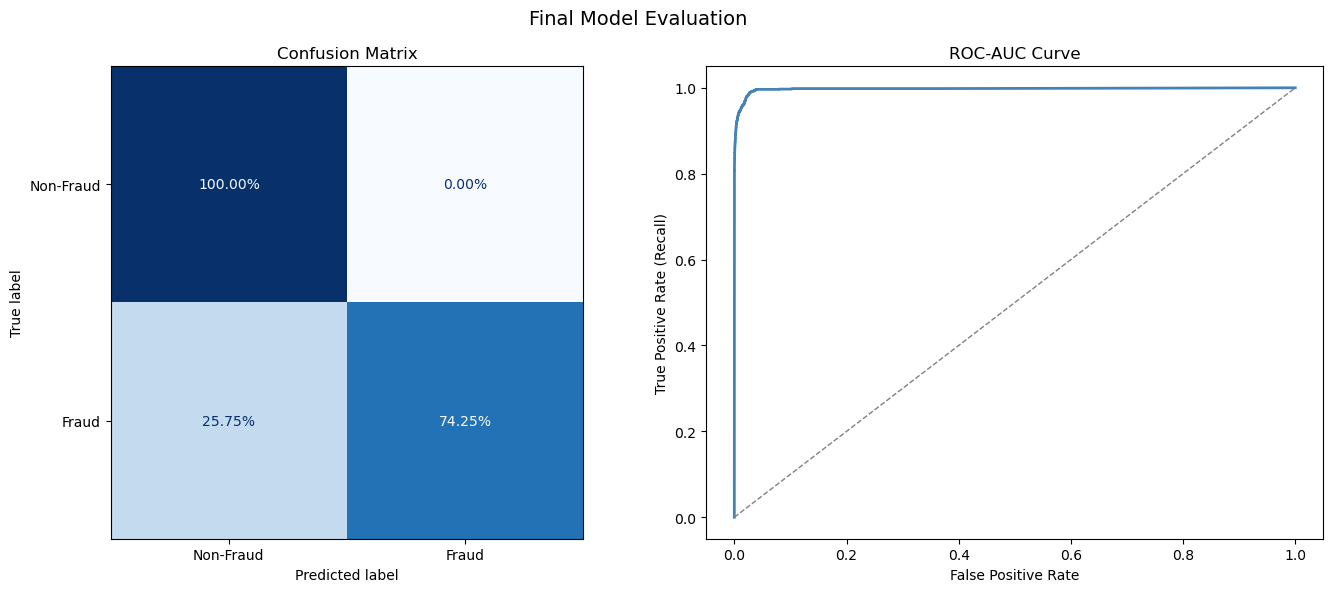

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Final Model Evaluation', fontsize=14)

# ── Confusion Matrix Heatmap ─────────────────────────────────────
cm = confusion_matrix(y_test, yhat_best, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Non-Fraud', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='.2%')
axes[0].set_title('Confusion Matrix')

# ── ROC-AUC Curve ────────────────────────────────────────────────
y_prob = rf_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Random Forest (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', 
             linewidth=1, label='Random Guess')
axes[1].set_title('ROC-AUC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')

plt.tight_layout()
plt.show()

In [29]:
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.9972


**Confusion Matrix**
Approximately:
On Non-Fraudulent transactions:
- 100.00% of non-fraud transactions were correctly identified
- 0.00% false alarm rate

<br>
<br>

On Fraudulent Transactions:
- 74.25% of fraud transactions were caught
- 25.75% of fraud transactions were MISSED!



**ROC-AUC Curve**
When our model evaluates a transaction, it doesn't just say "fraud" or "not fraud" — it assigns a probability score between 0 and 1 representing how confident it is that the transaction is fraudulent. The ROC-AUC curve visualizes how well those probability scores separate fraud from non-fraud across every possible decision threshold.

The AUC score of 0.9972 means that the model is actually very good at identifying which transactions look suspicious. The issue is that by default, the model only flags something as fraud if it is at least 50% confident. Some of the 423 missed fraud cases are likely sitting just below that 50% cutoff. Simply lowering that threshold — say to 30% — would likely catch more fraud without needing to retrain the model at all.

In [30]:
# Lower threshold from 0.50 to 0.30
y_prob = rf_best.predict_proba(X_test)[:, 1]
yhat_adjusted = (y_prob >= 0.30).astype(int)

print("ADJUSTED THRESHOLD (0.30)")
print(f"F1 Score: {f1_score(y_test, yhat_adjusted):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, yhat_adjusted)}")

=== ADJUSTED THRESHOLD (0.30) ===
F1 Score: 0.8462

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.94      0.77      0.85      1643

    accuracy                           1.00   1272524
   macro avg       0.97      0.88      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



By lowering the decision threshold from 0.50 to 0.30, recall improved from 74.25% to 77% while precision only dropped slightly from 96% to 94%. This simple adjustment required no retraining and resulted in a marginally better F1 score of 0.8462, confirming that threshold tuning is a quick and effective way to optimize the precision-recall tradeoff for imbalanced datasets.

### Conclusion
We were able to complete our goal of creating a random forest model that detects fraudulent bank transactions by learning from our imbalanced dataset where only 0.13% of transactions were fraudulent out of about 6.3 million total transactions.

We started by exploring our dataset learning a few thing like: only specific type of transactions had fraudulent case or that amounts on fraudulent transactions were approximately 8x bigger than legitimate ones. 

Because of these learnings, we were confident to drop a few features and add three new engineered features (balance_delta_orig, balance_delta_dest, and balance_mismatch) to directly capture the fraud patterns we identified in our EDA. Then we did one-hot encoding on the type feature to convert this feature into numerical columns.

Our baseline model's F1 Score ended up very slightly higher than our tuned model (from 0.8488 to 0.8437). Both models catch approximately 74-76% of fraudulent cases and correctly flags them 96% of the time. The limitation is that 25.75% of fraud cases go undetected. 

Our model's precision is 96%, meaning that when it flags a transaction as fraud, it is right almost every time, very few false alarms. However, the model misses 423 actual fraud cases, which is 25.75% of all real fraud in our test set, a low recall. 
The AUC score of 0.9972 means that the model is actually very good at identifying which transactions look suspicious. The issue is that by default, the model only flags something as fraud if it is at least 50% confident. Some of the 423 missed fraud cases are likely sitting just below that 50% cutoff.
By lowering the decision threshold from 0.50 to 0.30, recall improved from 74.25% to 77% while precision only dropped slightly from 96% to 94%. This simple adjustment required no retraining and resulted in a slightly better F1 score of 0.8462.
In short, the F1 score tells us how the model performs at the 50% cutoff, while the AUC tells us how good the model is at ranking risk overall. The adjustment we made on the threshold also confirms that tuning it is a quick and effective way to optimize the precision-recall tradeoff for imbalanced datasets.


Based on these finding, our model can be improved upon by 
- attempting to apply SMOTE to generate more synthetic fraud examples for training, or increase class weights to make the model pay more attention to fraud cases. Both would help catch more fraud, though some precision would likely be lost in the process.
- continuing to explore how the Gradient Boost Model performs (either by running it on a data sample to reduce computation time, or by allocating more time and resources for a full run)
- attempting to do a GridSearch on the Random Forest model if given the time and resources







